# Loss of a single MOSFET

## 0.IMPORT

In [1]:
# --- Configuration: run this first -------------------------------------------
import sys
from pathlib import Path

# Walk up to the project root (the folder holding DATABASE/)
ROOT = Path.cwd()
while not (ROOT / "DATABASE").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
    
from SRC.OTHERS.notebook import *

import matplotlib
SHOW_PLOTS = False
if not SHOW_PLOTS:
    matplotlib.use("Agg")  # no window: write the files straight out

import matplotlib.pyplot as plt

from DATABASE.db_driver_mosfet import DRIVER_LIBRARY, load_driver
from DATABASE.db_mosfet import MOSFET_LIBRARY, load_mosfet
from SRC.MOSFET.mosfet_loss import (
    OPERATING_POINT,
    loss_single_mosfet_at_temp,
    loss_thermal_iteration,
)
from SRC.MOSFET.mosfet_plot import (
    loss_table,
    plot_loss_breakdown,
    plot_thermal_iteration,
)
from SRC.OTHERS.plot import save_figure
from SRC.OTHERS.terminal import (
    alert,
    blank,
    dataframe,
    kv,
    section,
    table,
    use_theme,
)
from SRC.THERMAL.dissipator import PCBDissipator, Placement, StandardDissipator

## 1. IMAGES


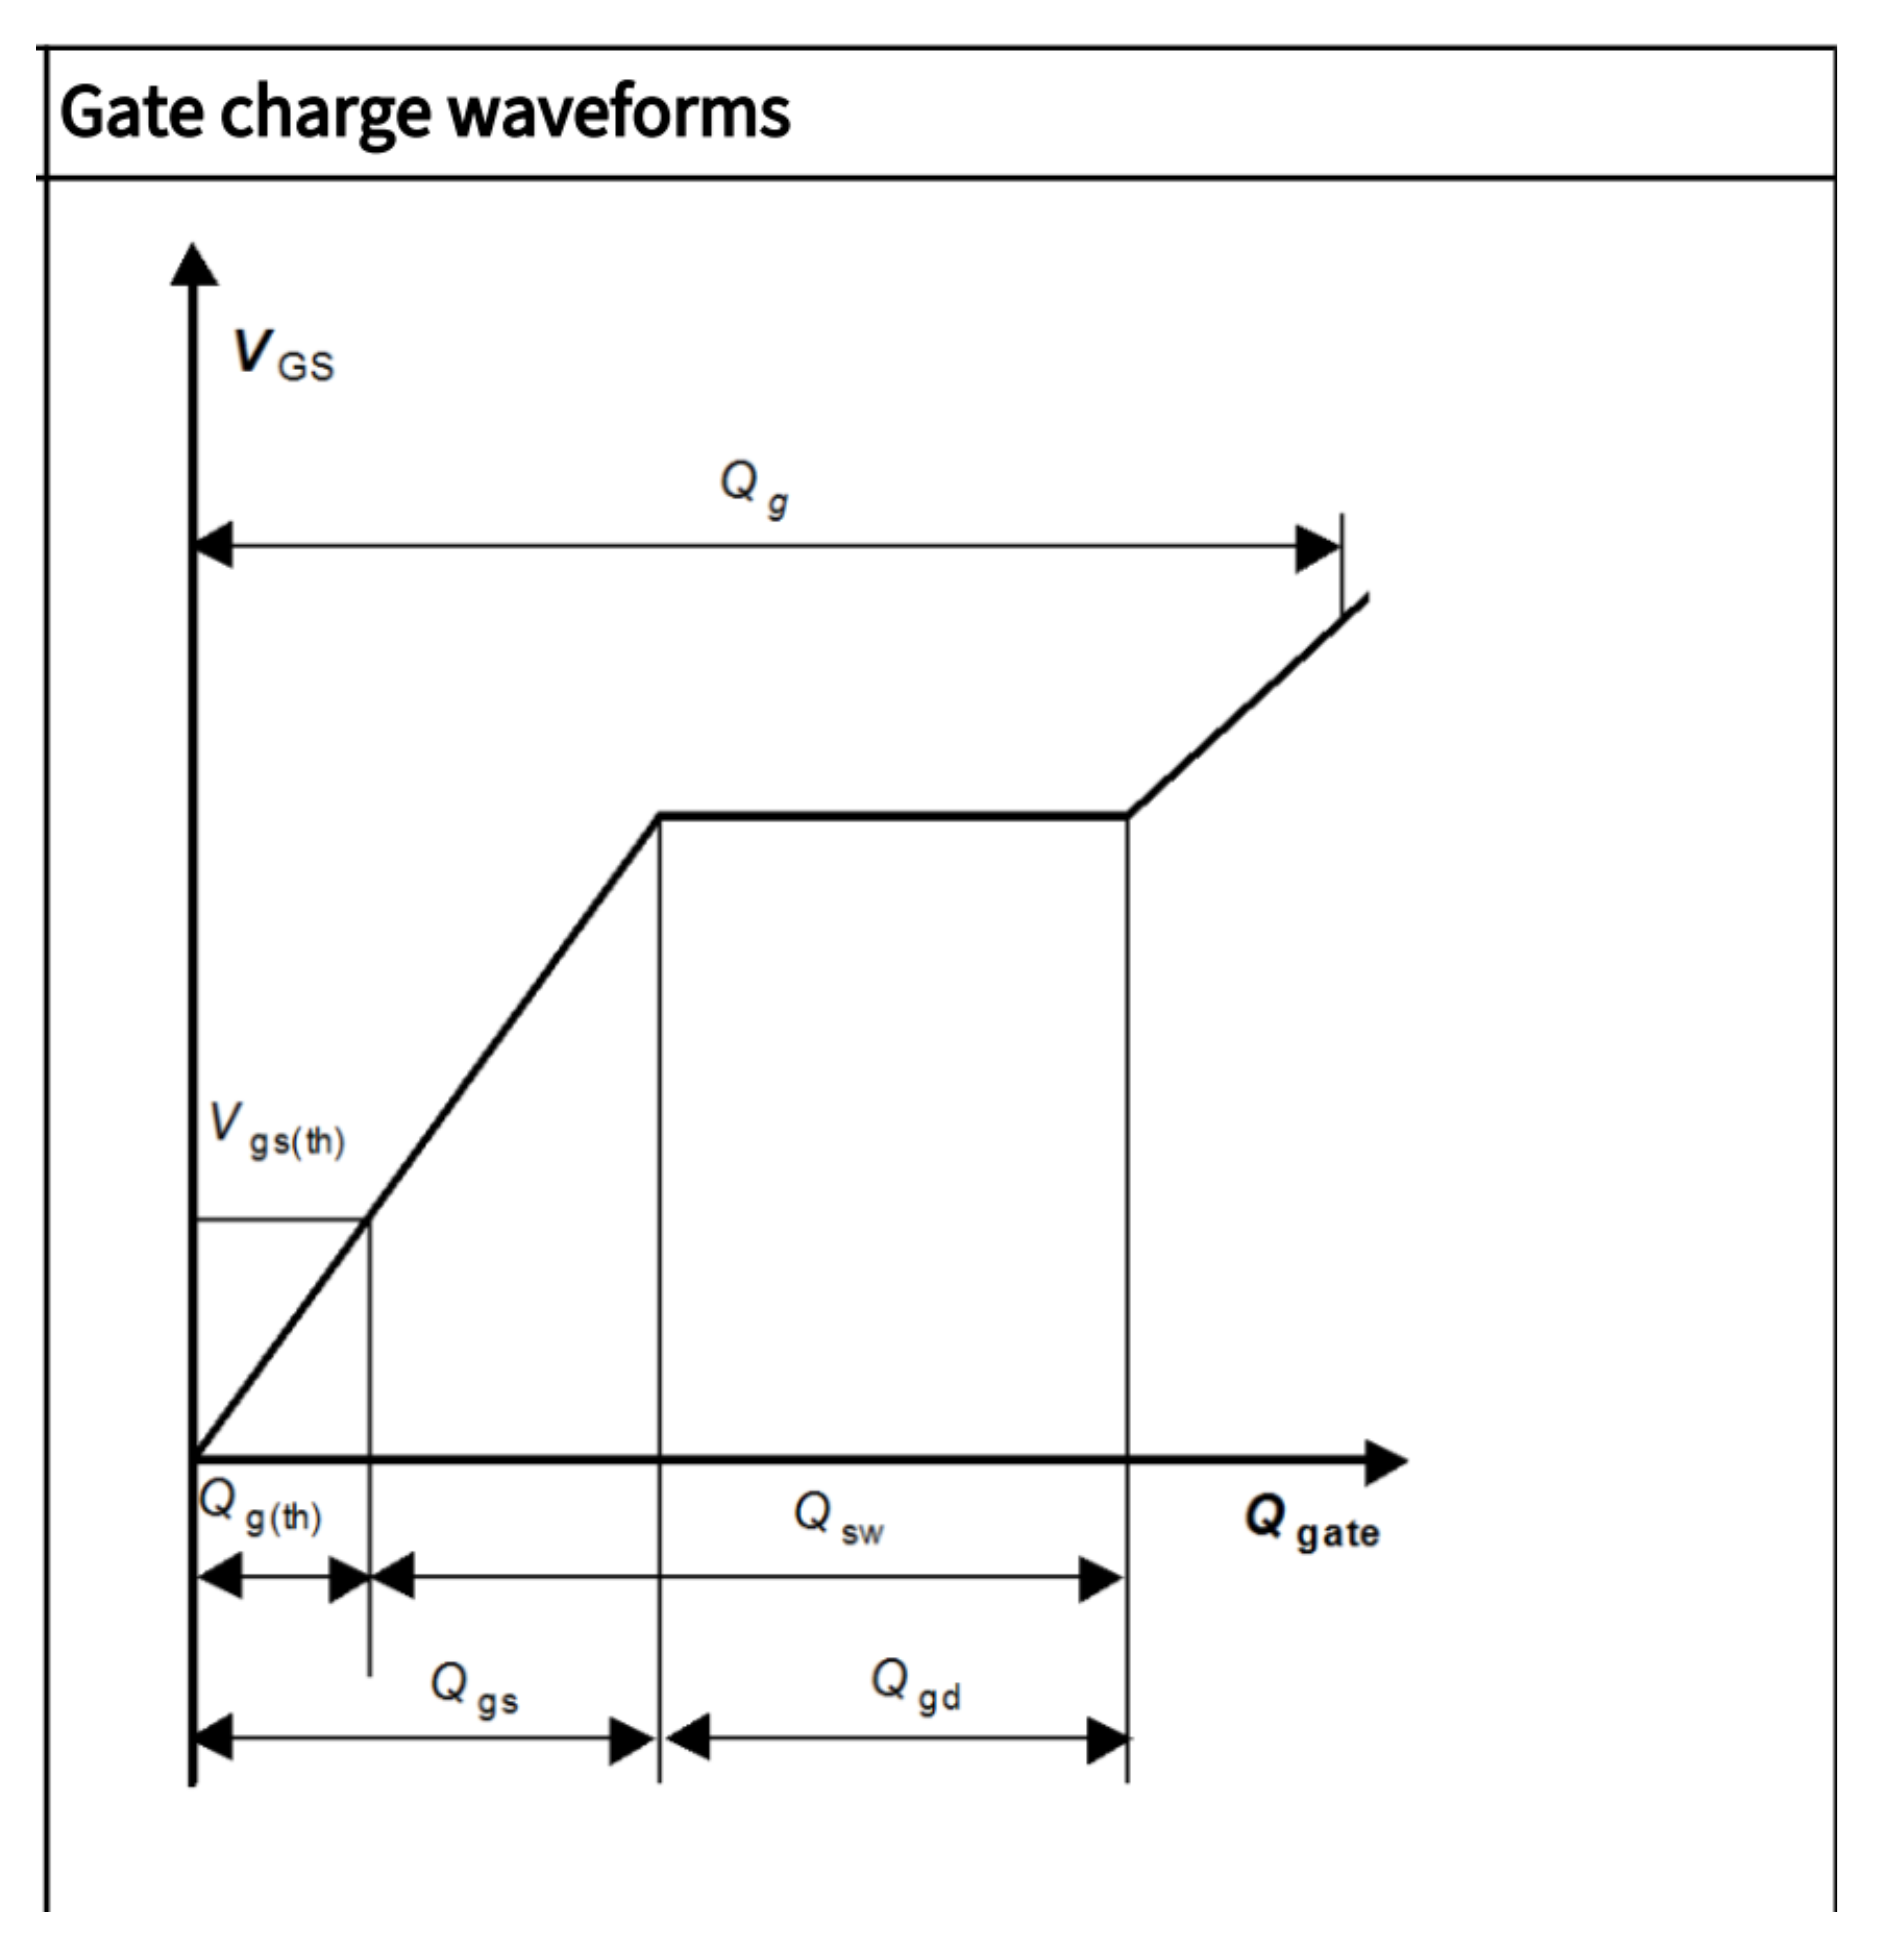
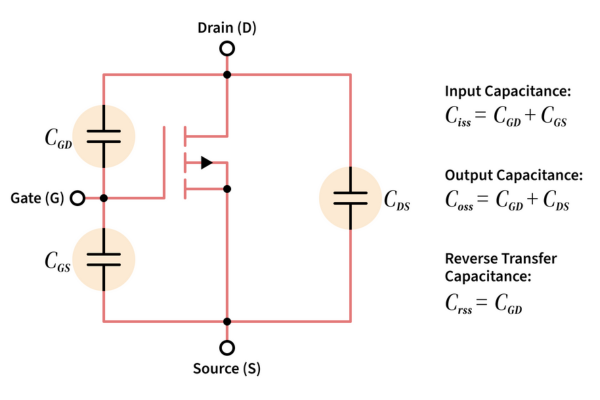
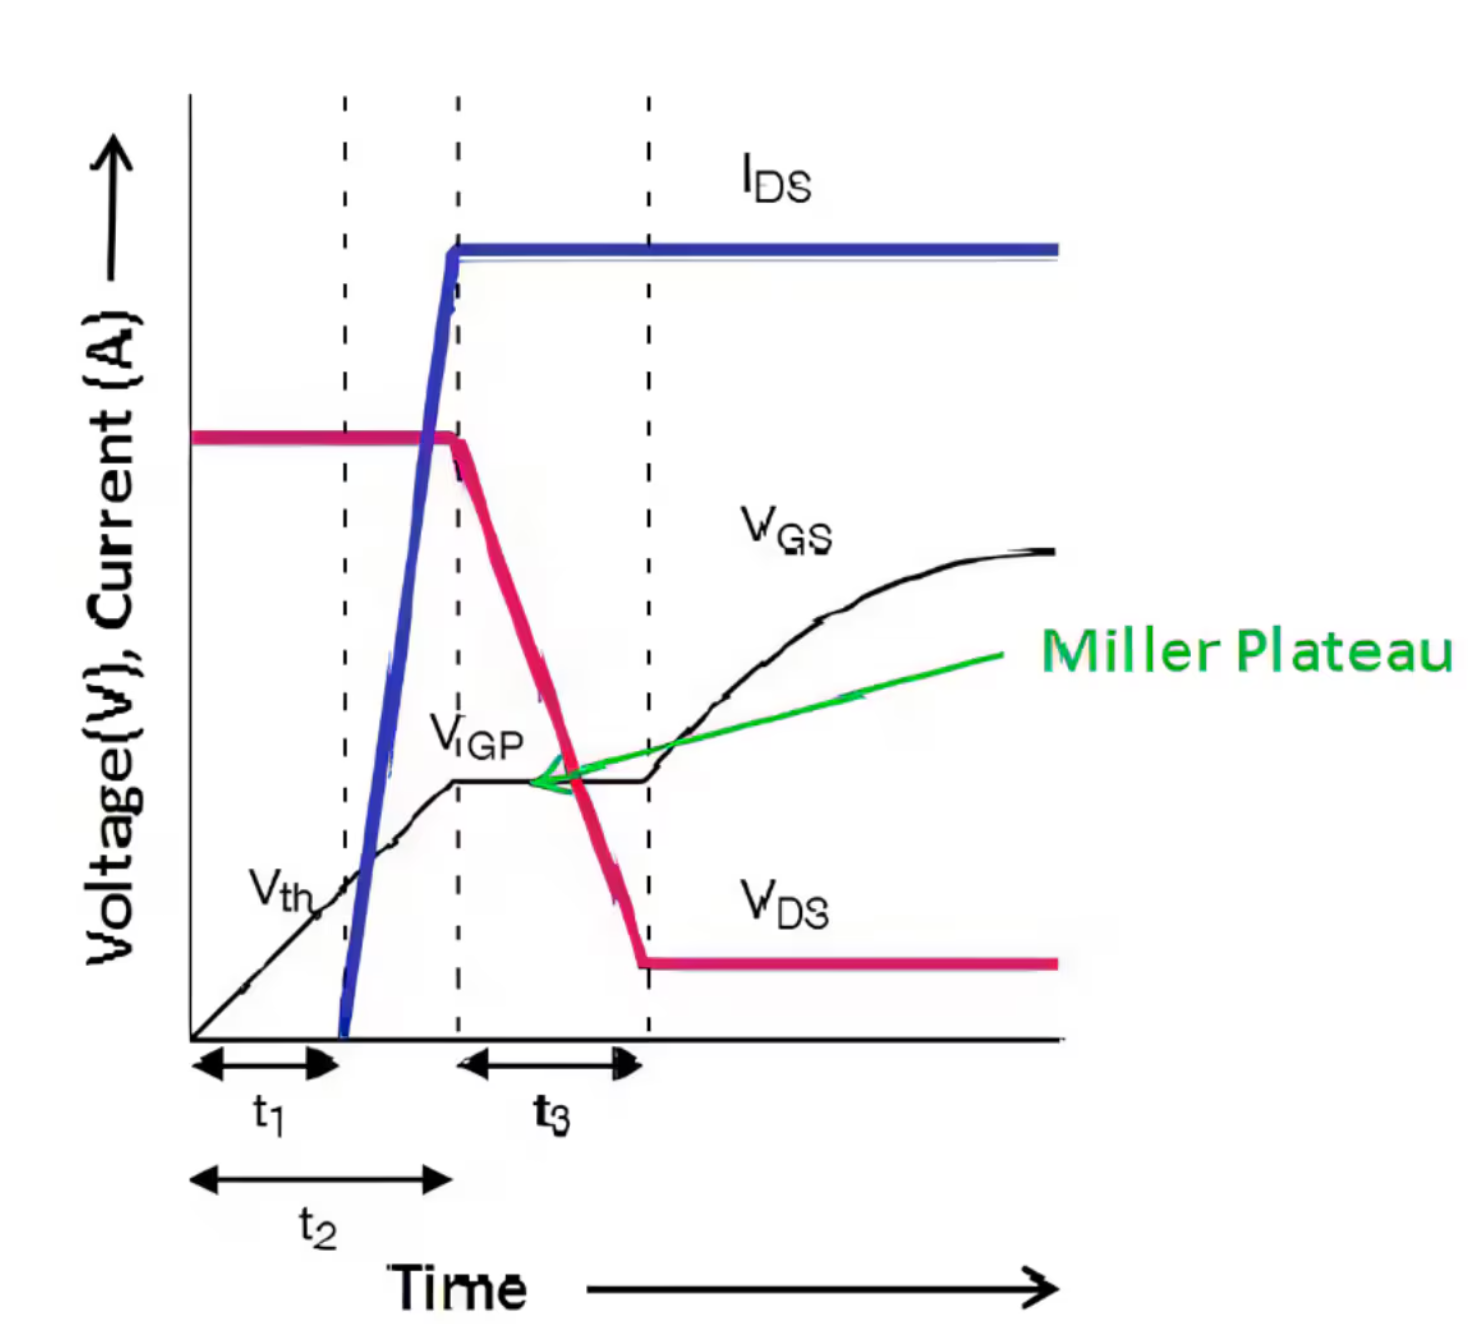

In [2]:
# --- Reference image ---------------------------------------------------------
mes_images = [
    ROOT / "DOCUMENTS/TRANSISTOR/MOSFET/gate_charge.png", 
    ROOT / "DOCUMENTS/TRANSISTOR/MOSFET/mosfet.webp",
    ROOT / "DOCUMENTS/TRANSISTOR/MOSFET/switching_waveform.png",
]
display(gallery(mes_images, width=1500, columns=3))
# image_box, image_dd = image_picker(ROOT / "DOCUMENTS", default="gate_charge")
# display(image_box)

## 2. FORMULA

<div style="font-family: system-ui, -apple-system, sans-serif; color: #334155; line-height: 1.6; background-color: #f8fafc; padding: 24px; border-radius: 8px; border: 1px solid #e2e8f0;">

<h3 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 8px; margin-top: 0;">2.1 Gate Loop Dynamics</h3>
The switching times are governed by the gate drive loop and the MOSFET's intrinsic charges.

<span style="color: #2563eb; font-weight: 600;">Gate Current</span>

$$I_G = \frac{V_{drive} - V_{gate}}{R_{G,tot}} \qquad \text{where} \quad R_{G,tot} = R_{drv} + R_{ext} + R_{g,int}$$

<span style="color: #64748b; font-style: italic; font-size: 0.9em;">(Note: $I_G$ is clamped to the driver's peak current rating)</span>

Switching transitions split into two distinct sub-intervals:

| Interval | Charge | Gate Voltage | Phenomenon |
| :--- | :--- | :--- | :--- |
| **<span style="color: #2563eb;">$t_{ri}$</span>** | $Q_{gs} - Q_{g(th)}$ | $\tfrac12(V_{th}+V_{pl})$ | Current rises, $V_{ds}$ stays high |
| **<span style="color: #2563eb;">$t_{fv}$</span>** | $Q_{gd}$ | $V_{pl}$ (Plateau) | Voltage falls |

<span style="color: #64748b; font-style: italic; font-size: 0.9em;">Turn-off follows the mirror image ($t_{rv}$ for voltage rise, $t_{fi}$ for current fall).</span>
$$t_{on} = t_{ri} + t_{fv} \qquad t_{off} = t_{rv} + t_{fi}$$

<br>

<h3 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 8px;">2.2 The Six Loss Components</h3>
Total junction temperature is driven by six distinct sources of dissipation.

<span style="color: #2563eb; font-weight: 600;">1. Conduction Loss</span> <span style="color: #64748b; font-size: 0.9em;">(Temperature dependent)</span>

$$P_{cond} = R_{DS(on)}(T_j)\; I_{rms}^2 \qquad \text{with} \quad R_{DS(on)}(T_j) = R_{25}\left[1 + \alpha_R (T_j - 25)\right]$$

<span style="color: #2563eb; font-weight: 600;">2. Switching Loss</span> <span style="color: #64748b; font-size: 0.9em;">(V-I overlap)</span>

$$P_{sw} = \frac{1}{2}\left(V_{on} I_{on} t_{on} + V_{off} I_{off} t_{off}\right) f_{sw}$$

<span style="color: #2563eb; font-weight: 600;">3. Output Capacitance Loss</span>

$$P_{oss} = \frac{1}{2}\, C_{oss,er}(V_{on})\, V_{on}^2\, f_{sw}$$

<span style="color: #2563eb; font-weight: 600;">4. Body Diode & Reverse Recovery</span>

$$P_{body} = \underbrace{V_F I_{body} D_{body}}_{\text{Dead-time}} + \underbrace{Q_{rr}\, V_{on}\, f_{sw}}_{\text{Recovery}}$$

<span style="color: #b91c1c; font-weight: 600;">⚠️ Note:</span> <span style="color: #ef4444; font-style: italic;">$Q_{rr}$ belongs to the <strong>facing</strong> diode (freewheel/sync-rect), not this MOSFET.</span>

<span style="color: #2563eb; font-weight: 600;">5. Internal Gate Loss</span>

$$P_{g,int} = (Q_g\, \Delta V_{gs}\, f_{sw}) \times \frac{R_{g,int}}{R_{G,tot}}$$

<span style="color: #64748b; font-style: italic; font-size: 0.9em;">Only the internal resistance fraction heats the silicon die.</span>

<span style="color: #0f172a; font-weight: 600;">Total Power Dissipation:</span>

$$P_{total} = P_{cond} + P_{sw} + P_{oss} + P_{body} + P_{g,int}$$

<br>

<h3 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 8px;">2.3 Thermal Coupling & Runaway</h3>
$R_{DS(on)}$ rises with $T_j$, and $T_j$ rises with power loss. The model iterates to a fixed point:

$$T_j^{(k+1)} = T_{amb} + R_{thJA} \cdot P_{total}\!\left(T_j^{(k)}\right)$$

<span style="color: #b91c1c; font-style: italic; font-size: 0.9em;">(If the iteration diverges, the model flags a <strong>thermal runaway</strong> condition).</span>

<br>

<h3 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 8px;">2.4 Switching Modes Matrix</h3>
The model does not use a binary "Hard/Soft" toggle. Instead, losses are derived directly from the swept voltages:

| Topology / Mode | $V_{turn\,on}$ | $V_{turn\,off}$ |
| :--- | :--- | :--- |
| **<span style="color: #059669;">Hard Switching</span>** | $V_{bus}$ | $V_{bus}$ |
| **<span style="color: #059669;">ZVS Turn-on</span>** <span style="color: #64748b; font-size: 0.85em;">(e.g. LLC, Phase-Shift)</span> | $0$ | $V_{bus}$ |
| **<span style="color: #059669;">ZVS Both Edges</span>** | $0$ | $0$ |
| **<span style="color: #059669;">Snubbed Turn-off</span>** | $V_{bus}$ | Fraction of $V_{bus}$ |

<span style="color: #64748b; font-style: italic; font-size: 0.9em;">(Setting $V_{turn\,on} = 0$ inherently zeros both $P_{oss}$ and the recovery loss).</span>

<br>

<h3 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 8px;">2.5 Cooling Paths</h3>
Total junction-to-ambient resistance ($R_{thJA}$) is computed by treating each package face as a parallel cooling branch.

```text
                            ( Junction: T_j )
                                   │
                 ┌─────────────────┴─────────────────┐
    R_thJC(bottom) [Datasheet]         R_thJC(top) [Datasheet]
                 │                                   │
      R_ext(bottom) [Dissipator]          R_ext(top) [Dissipator]
                 │                                   │
                 └─────────────────┬─────────────────┘
                                   │
                          ( Ambient: T_ambient )
```

<span style="color: #2563eb; font-weight: 600;">Equivalent Thermal Resistance</span>

$$R_{thJA} = \left[\;\sum_{\text{active faces}} \frac{1}{R_{thJC,f} + R_{ext,f}}\right]^{-1}$$

The system supports two dissipation models via <span style="font-family: monospace; color: #7c3aed; background-color: #f3f4f6; padding: 2px 6px; border-radius: 4px;">SRC/THERMAL/dissipator.py</span>:

| Class | Inputs | Target Application |
| :--- | :--- | :--- |
| <span style="color: #7c3aed; font-family: monospace;">StandardDissipator</span> | $R_{th}$ + $R_{TIM}$ | Heatsinks, thermal pads, baseplates |
| <span style="color: #7c3aed; font-family: monospace;">PCBDissipator</span> | Geometry (Cu thickness, vias) | Bare FR4, copper planes |

<span style="color: #64748b; font-style: italic; font-size: 0.9em;">(For <span style="font-family: monospace;">PCBDissipator</span>, the effective thermal spreading area is constrained to:)</span>
$$r_{max} = 1.5\,\text{cm}\times\sqrt{\frac{t_{cu}}{35\,\mu m}}$$

</div>

## 3. TO MODIFY

In [3]:
# --- Components --------------------------------------------------------------
MOSFET = "BSC016N06NS"
DRIVER = "UCC27714"

# --- Operating point ---------------------------------------------------------
V_TURN_ON = 48.0  # V_ds swept at turn-on [V]
V_TURN_OFF = 48.0  # V_ds swept at turn-off [V]
I_RMS = 15.8  # conduction rms current [A]
I_ON = 25.0  # current commutated at turn-on [A]
I_OFF = 25.0  # current commutated at turn-off [A]
F_SW_KHZ = 100.0  # switching frequency [kHz]

# --- Gate loop ---------------------------------------------------------------
R_G_EXT_ON = 2.2  # external gate resistor, turn-on [ohm]
R_G_EXT_OFF = 1.0  # external gate resistor, turn-off [ohm]

# --- Body diode / reverse recovery -------------------------------------------
I_BODY = 0.0  # diode current during the dead time [A]
D_BODY_PCT = 0.0  # diode conduction duty cycle [%]

# Charge the turn-on has to sweep out of the facing diode, entered by hand.
Q_RR_NC = 0.0  # [nC]

# --- Thermal -----------------------------------------------------------------
T_J_EVAL = 100.0  # Tj the loss budget is evaluated at [°C]
T_AMBIENT = 40.0  # ambient temperature of the thermal iteration [°C]

# R_TH_SOURCE:
#   "dissip"    -> computed face by face from FACES (see below)
#   "datasheet" -> bare R_thJA from the datasheet
#   "manual"    -> the value entered in R_TH_MANUAL
R_TH_SOURCE = "dissip"
R_TH_MANUAL = 20.0  # R_th junction -> ambient [°C/W], if R_TH_SOURCE == "manual"

# --- Cooling, one block per package face -------------------------------------
# Every active face opens a R_thJC(face) + R_ext(face) branch; the branches add
# up in parallel. The datasheet R_thJA is then unused (it already assumes a
# copper plane: keeping it would count the same PCB twice).
#
# mode :  "none" (uncooled face) | "pcb" (copper plane) | "std" (heatsink)
#
# Common substrates — (k [W/(m·K)], typical thickness [mm]):
#   standard FR4   (0.3,  1.6)      DBC Al2O3  (25.0,  0.38)
#   IMS alu base   (2.0,  0.1)      DBC AlN    (170.0, 0.63)
#
FACES = {
    "bottom": {
        "mode": "pcb",
        "pcb": {
            "A_cu_total_side_cm2": 10.0,  # total copper on this side [cm²]
            "A_cu_other_side_cm2": 10.0,  # copper on the far side [cm²] (0 = none)
            "A_pad_mosfet_cm2": 0.3,  # thermal pad area [cm²]
            "copper_thickness_um": 70.0,  # copper thickness [µm] (35 = 1 oz)
            "pcb_thickness_mm": 1.6,
            "pcb_k_W_mK": 0.3,
            "k_conductor_W_mK": 385.0,
            "n_vias": 24,
            "via_diameter_mm": 0.3,
            "via_plating_um": 25.0,
            "via_filled": False,
            "h_conv_eff_W_m2K": 25.0,  # convection + radiation [W/(m²·K)]
        },
        "std": {"R_th": 5.0, "R_tim": 0.5},  # heatsink, when mode == "std"
    },
    "top": {
        "mode": "none",
        "pcb": {
            "A_cu_total_side_cm2": 2.0,
            "A_cu_other_side_cm2": 0.0,
            "A_pad_mosfet_cm2": 0.3,
            "copper_thickness_um": 70.0,
            "pcb_thickness_mm": 1.6,
            "pcb_k_W_mK": 0.3,
            "k_conductor_W_mK": 385.0,
            "n_vias": 0,
            "via_diameter_mm": 0.3,
            "via_plating_um": 25.0,
            "via_filled": False,
            "h_conv_eff_W_m2K": 25.0,
        },
        "std": {"R_th": 5.0, "R_tim": 0.5},
    },
}

# --- Output ------------------------------------------------------------------
SHOW_PLOTS = False  # open the figures in a window
SAVE_PLOTS = True  # write the figures to OUTPUT/
# Figure theme. "light" / "dark" are the neutral pair; "red", "blue" and "vivid"
# are accent themes on a tinted black. Full list in SRC/OTHERS/plot.py.
PLOT_THEME = "light"

PLOT_FORMATS = ("png", "svg", "pdf")
PLOT_DPI = 300  # raster resolution; ignored by svg / pdf


TERMINAL_THEME = "dark"
OUTPUT_DIR = ROOT / "OUTPUT"

## 4. DON'T TOUCH

In [4]:
use_theme(TERMINAL_THEME)


def fmt_r(value: float) -> str:
    """A thermal resistance, infinity included (missing via = open path)."""
    return "inf" if value > 1e6 else f"{value:.1f}"


# An alert is a (level, message) pair: "stop" aborts the calculation, "warn"
# only goes along with it. The two factories below save writing the level by
# hand every time.
def stop(message: str) -> tuple[str, str]:
    return "stop", message


def warn(message: str) -> tuple[str, str]:
    return "warn", message


# ============================================================================ #
#  Building the operating point and the dissipators
# ============================================================================ #


def build_operating_point() -> OPERATING_POINT:
    return OPERATING_POINT(
        v_turn_on=V_TURN_ON,
        v_turn_off=V_TURN_OFF,
        i_rms=I_RMS,
        f_sw=F_SW_KHZ * 1e3,
        i_on=I_ON,
        i_off=I_OFF,
        r_g_ext_on=R_G_EXT_ON,
        r_g_ext_off=R_G_EXT_OFF,
        i_body=I_BODY,
        d_body=D_BODY_PCT / 100.0,
        q_rr_opposite=Q_RR_NC * 1e-9,
    )


def build_dissipators() -> list:
    """The dissipators of the active faces, in the order of FACES."""
    built = []
    for face, cfg in FACES.items():
        mode = cfg["mode"]
        if mode == "none":
            continue
        placement = Placement(face)
        if mode == "std":
            built.append(
                StandardDissipator(
                    name=f"Heatsink {face}", placement=placement, **cfg["std"]
                )
            )
        elif mode == "pcb":
            params = dict(cfg["pcb"])
            # 0 cm² on the far side = no opposite plane at all (path B closed)
            params["A_cu_other_side_cm2"] = params.get("A_cu_other_side_cm2") or None
            built.append(
                PCBDissipator(
                    name=f"Copper plane {face}", placement=placement, **params
                )
            )
        else:
            raise ValueError(f"unknown FACES['{face}']['mode']: {mode!r}")
    return built


def resolve_r_th(mosfet) -> tuple[float | None, list[tuple[str, str]], list]:
    """
    (r_th, alerts, dissipators) according to R_TH_SOURCE.

    r_th = None lets loss_thermal_iteration fall back to the datasheet R_thJA.
    """
    if R_TH_SOURCE == "manual":
        return R_TH_MANUAL, [], []
    if R_TH_SOURCE == "datasheet":
        return None, [], []
    if R_TH_SOURCE != "dissip":
        raise ValueError(f"unknown R_TH_SOURCE: {R_TH_SOURCE!r}")

    try:
        active = build_dissipators()
    except ValueError as err:  # geometry rejected by pydantic (ValidationError)
        detail = str(err).split("Value error, ")[-1].split(" [type=")[0].strip()
        return None, [stop(f"Invalid dissipator geometry — {detail}")], []

    if not active:
        message = warn(
            "No cooled face: falling back to the datasheet R_thJA "
            f"({mosfet.thermal.r_thja[0]:.0f} °C/W). Enable at least one face "
            "in FACES."
        )
        return None, [message], []

    available_faces = [face for _, face in mosfet.thermal.r_thjc]
    missing = [
        d.placement.value for d in active if d.placement.value not in available_faces
    ]
    if missing:
        message = stop(
            f'{MOSFET} has no R_thJC for the "{missing[0]}" face '
            f"(available: {', '.join(available_faces)}). Fill in `r_thjc` in "
            "MOSFET_LIBRARY."
        )
        return None, [message], []

    alerts: list[tuple[str, str]] = []
    pcbs = [d for d in active if isinstance(d, PCBDissipator)]

    # A PCB only has two planes: declaring both sides counts the copper twice.
    if len(pcbs) > 1 and all(p.A_cu_other_side_cm2 for p in pcbs):
        alerts.append(
            warn(
                'Both faces are in "pcb" mode and each declares an opposite plane: '
                "the same copper is counted twice. Set A_cu_other_side_cm2 to 0 on "
                "one of them."
            )
        )
    # Copper beyond the spreading radius: paid for in board area, useless thermally.
    for p in pcbs:
        if p.A_cu_effective_side_cm2 < p.A_cu_total_side_cm2 - 1e-9:
            alerts.append(
                warn(
                    f"{p.name}: only {p.A_cu_effective_side_cm2:.1f} cm² of the "
                    f"{p.A_cu_total_side_cm2:.1f} cm² declared take part (spreading "
                    f"radius at {p.copper_thickness_um:.0f} µm). Widening the plane "
                    "will not help any more: thicker copper, vias, or airflow."
                )
            )

    paths = [(d.get_rth(), d.placement.value) for d in active]
    return mosfet.thermal.r_thja_value(paths), alerts, active


def check_operating_point(mosfet, op: OPERATING_POINT) -> list[tuple[str, str]]:
    """Consistency of the operating point against the part's ratings."""
    alerts: list[tuple[str, str]] = []
    v_max_coss = mosfet.c_oss.vds_points[-1]
    v_sw = max(op.v_turn_on, op.v_turn_off)

    if v_sw > mosfet.v_dss_max:
        alerts.append(
            stop(
                f"Switched voltage {v_sw:.0f} V above the V_DSS rating of the "
                f"{mosfet.component_info.part_number} ({mosfet.v_dss_max:.0f} V) "
                "— breakdown."
            )
        )
    if op.v_turn_on > v_max_coss:
        alerts.append(
            stop(
                f"The datasheet C_oss curve stops at {v_max_coss:.0f} V: P_oss "
                f"cannot be computed at {op.v_turn_on:.0f} V without extrapolating. "
                "Extend `vds_points` / `coss_points` in MOSFET_LIBRARY."
            )
        )
    for name, value in (
        ("I_rms", op.i_rms),
        ("Turn-on current", op.i_commutated_on()),
        ("Turn-off current", op.i_commutated_off()),
    ):
        if value > mosfet.i_max:
            alerts.append(
                warn(
                    f"{name} = {value:.0f} A above the current rating "
                    f"({mosfet.i_max:.0f} A)."
                )
            )
    if T_J_EVAL > mosfet.thermal.t_j_max:
        alerts.append(
            warn(
                f"Evaluation Tj {T_J_EVAL:.0f} °C above T_j,max "
                f"({mosfet.thermal.t_j_max:.0f} °C)."
            )
        )
    # P_rr = Q_rr * V_turn_on * f_sw: under ZVS nothing forces a recovery, so the
    # charge entered costs nothing. Worth saying out loud.
    if Q_RR_NC > 0.0 and op.v_turn_on == 0.0:
        alerts.append(
            warn(
                f"Q_rr = {Q_RR_NC:.0f} nC entered but V_TURN_ON = 0 (ZVS): P_rr = "
                "Q_rr · V_turn_on · f_sw is zero anyway. The value has no effect on "
                "the budget."
            )
        )
    return alerts


# ============================================================================ #
#  Report
# ============================================================================ #


def report_operating_point(mosfet) -> None:
    section(1, "Operating point")
    kv("MOSFET", f"{MOSFET}  ({mosfet.component_info.package})")
    kv("Driver", DRIVER)
    kv("Switched voltage on / off", f"{V_TURN_ON:.0f} V / {V_TURN_OFF:.0f} V")
    kv("Current I_rms / I_on / I_off", f"{I_RMS:.1f} A / {I_ON:.1f} A / {I_OFF:.1f} A")
    kv("Switching frequency", f"{F_SW_KHZ:.0f} kHz")
    kv("External gate R on / off", f"{R_G_EXT_ON:.2f} / {R_G_EXT_OFF:.2f} ohm")
    kv("Body diode: I_body / D_body", f"{I_BODY:.1f} A / {D_BODY_PCT:.1f} %")
    kv(
        "Q_rr of the facing diode",
        f"{Q_RR_NC:.0f} nC" + ("  (no recovery)" if Q_RR_NC == 0 else "  (entered)"),
    )
    kv("Evaluation Tj / ambient", f"{T_J_EVAL:.0f} °C / {T_AMBIENT:.0f} °C")


def report_thermal_paths(mosfet, active: list, r_th: float) -> None:
    """One line per branch, then the internals of the PCB planes."""
    section(2, "Thermal paths")
    rows = []
    for d in active:
        r_jc = mosfet.thermal.r_thjc_value(d.placement.value)
        r_ext = d.get_rth()
        rows.append((d.name, f"{r_jc:.2f}", fmt_r(r_ext), f"{r_jc + r_ext:.1f}"))
    table(["Branch", "R_thJC", "R_ext", "Total [°C/W]"], rows)
    blank()
    kv("Branches in parallel -> R_thJA", f"{r_th:.1f} °C/W")
    kv("(bare datasheet, unused here)", f"{mosfet.thermal.r_thja[0]:.0f} °C/W")

    detail = [
        ("r_spreading_max_cm", "max spreading radius [cm]"),
        ("A_cu_effective_side_cm2", "useful copper, pad side [cm²]"),
        ("A_cu_exposed_side_cm2", "copper exposed to air [cm²]"),
        ("R_conv_side", "R convection, pad side (path A)"),
        ("R_pcb_thru", "R bare substrate under the pad"),
        ("R_vias", "R thermal vias"),
        ("R_through", "R crossing (substrate || vias)"),
        ("R_conv_other", "R convection, far side"),
        ("R_path_B", "path B total"),
        ("R_total", "R_ext of the face (A || B)"),
    ]
    for d in active:
        if not isinstance(d, PCBDissipator):
            continue
        breakdown = d.breakdown()
        blank()
        kv(f"Detail — {d.name}", "[cm, cm², °C/W]")
        table(
            ["Item", "Value"],
            [
                (label, fmt_r(breakdown[key]))
                for key, label in detail
                if key in breakdown
            ],
        )


def report_losses(res) -> None:
    section(3, "Loss budget [W]")
    dataframe(loss_table(res))
    blank()
    kv(
        "Total dissipated in the die",
        f"{res.p_total:.3f} W  (at Tj = {T_J_EVAL:.0f} °C)",
    )
    kv("Off-package — driver", f"{res.p_gate_drv * 1e3:.0f} mW")
    kv("Off-package — external gate R", f"{res.p_gate_ext * 1e3:.0f} mW")


def report_switching(mosfet, res) -> None:
    section(4, "Switching")
    table(
        ["Sub-interval", "Duration [ns]", "Slew rate"],
        [
            (
                "t_ri (current rise)",
                f"{res.t_ri * 1e9:.1f}",
                f"di/dt on  {res.di_dt_on / 1e9:.2f} A/ns",
            ),
            (
                "t_fv (voltage fall)",
                f"{res.t_fv * 1e9:.1f}",
                f"dv/dt on  {res.dv_dt_on / 1e9:.2f} V/ns",
            ),
            (
                "t_rv (voltage rise)",
                f"{res.t_rv * 1e9:.1f}",
                f"dv/dt off {res.dv_dt_off / 1e9:.2f} V/ns",
            ),
            (
                "t_fi (current fall)",
                f"{res.t_fi * 1e9:.1f}",
                f"di/dt off {res.di_dt_off / 1e9:.2f} A/ns",
            ),
        ],
    )
    blank()
    kv("t_on / t_off", f"{res.t_on * 1e9:.1f} ns / {res.t_off * 1e9:.1f} ns")
    kv(
        f"R_DS(on) at {T_J_EVAL:.0f} °C",
        f"{res.r_ds_on * 1e3:.3f} mohm  "
        f"({res.r_ds_on / mosfet.r_ds_on.r_ds_on_25:.2f} x the value at 25 °C)",
    )


def report_thermal(mosfet, th, r_th_source_label: str) -> None:
    section(5, "Thermal coupling")
    t_j_max = mosfet.thermal.t_j_max
    kv("R_th junction -> ambient", f"{th.r_th:.1f} °C/W  ({r_th_source_label})")
    kv("Iterations", f"{th.iterations}  (converged={th.converged})")
    kv("Loss at the converged Tj", f"{th.loss.p_total:.3f} W")
    blank()
    if not th.converged:
        alert("error", "DIVERGES — thermal runaway.", prefix="Tj")
    elif th.t_j_max_exceeded:
        alert(
            "error",
            f"Tj = {th.t_j:.1f} °C, above T_j,max = {t_j_max:.0f} °C.",
            prefix="Tj",
        )
    else:
        alert(
            "ok",
            f"Tj = {th.t_j:.1f} °C, {t_j_max - th.t_j:.0f} °C of margin below "
            f"T_j,max = {t_j_max:.0f} °C.",
            prefix="Tj",
        )


def report_figures(mosfet, res, th) -> None:
    if not (SHOW_PLOTS or SAVE_PLOTS):
        return
    section(6, "Figures")

    fig_loss = plot_loss_breakdown(
        res,
        title=f"{MOSFET} — loss breakdown",
        subtitle=f"{V_TURN_ON:.0f} V / {I_ON:.0f} A / {F_SW_KHZ:.0f} kHz "
        f"at Tj = {T_J_EVAL:.0f} °C — total {res.p_total:.2f} W",
        theme=PLOT_THEME,
    )
    fig_th = plot_thermal_iteration(
        th,
        t_j_max=mosfet.thermal.t_j_max,
        title=f"{MOSFET} — Tj convergence",
        subtitle=f"R_th = {th.r_th:.0f} °C/W, T_amb = {T_AMBIENT:.0f} °C",
        theme=PLOT_THEME,
    )

    if SAVE_PLOTS:
        for fig, name in (
            (fig_loss, "single_mosfet_loss_breakdown"),
            (fig_th, "single_mosfet_thermal"),
        ):
            for path in save_figure(
                fig, OUTPUT_DIR / name, formats=PLOT_FORMATS, dpi=PLOT_DPI
            ):
                kv("written", str(path))

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig_loss)
        plt.close(fig_th)


# ============================================================================ #
#  Run
# ============================================================================ #


def main() -> int:
    kv("Project root", str(ROOT))
    kv("MOSFETs available", ", ".join(sorted(MOSFET_LIBRARY)))
    kv("Drivers available", ", ".join(sorted(DRIVER_LIBRARY)))

    mosfet = load_mosfet(MOSFET)
    driver = load_driver(DRIVER)
    op = build_operating_point()

    r_th, alerts_th, active = resolve_r_th(mosfet)
    alerts = check_operating_point(mosfet, op) + alerts_th
    if alerts:
        blank()
        for level, message in alerts:
            if level == "stop":
                alert("error", message, prefix="CANNOT COMPUTE")
            else:
                alert("warn", message)
    if any(level == "stop" for level, _ in alerts):
        return 1

    try:
        res = loss_single_mosfet_at_temp(mosfet, driver, op, t_j=T_J_EVAL)
    except ValueError as err:
        blank()
        alert("error", str(err), prefix="CANNOT COMPUTE")
        return 1

    th = loss_thermal_iteration(mosfet, driver, op, t_ambient=T_AMBIENT, r_th=r_th)

    label = {"dissip": "dissipators", "datasheet": "datasheet", "manual": "entered"}
    r_th_label = label[R_TH_SOURCE] if r_th is not None else "datasheet"

    report_operating_point(mosfet)
    # The branch detail only means something when the branches are what sets R_th.
    if active and r_th is not None:
        report_thermal_paths(mosfet, active, r_th)
    report_losses(res)
    report_switching(mosfet, res)
    report_thermal(mosfet, th, r_th_label)
    report_figures(mosfet, res, th)
    blank()
    return 0



<div style="font-family: system-ui, -apple-system, sans-serif;">

## 5. RESULT

In [5]:
main()

    Project root                                      c:\Users\tro\OneDrive - Danish Aerospace\Documents\Projects\Test\MyCalculator_V3
    MOSFETs available                                 BSC016N06NS
    Drivers available                                 UCC27714

1.  Operating point ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    MOSFET                                            BSC016N06NS  (SuperSO8)
    Driver                                            UCC27714
    Switched voltage on / off                         48 V / 48 V
    Current I_rms / I_on / I_off                      15.8 A / 25.0 A / 25.0 A
    Switching frequency                               100 kHz
    External gate R on / off                          2.20 / 1.00 ohm
    Body diode: I_body / D_body                       0.0 A / 0.0 %
    Q_rr of the facing diode                    

0